In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

In [21]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/Baeklab.070.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
label_df_filtered = label_df[((label_df["dom_label"] > 0.0) & (label_df["label"] == 1)) | (label_df["label"] == 0)]
print(label_df_filtered["label"].value_counts())



label
0    18399879
1      100118
Name: count, dtype: int64


In [27]:
cell_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup/pileup.pkl"
cell_df = pd.read_pickle(cell_df)
cell_df = cell_df[cell_df["count_pm6a"] >= 20]
cell_label_df = cell_df.merge(label_df_filtered, on="label_id", how="inner")
cell_label_df["threshold"] = 1-((0.9 ** (1-cell_label_df["dom"])) * (0.02 ** (cell_label_df["dom"])))
cell_label_df["discarded_ratio"] = (cell_label_df["count_dom"] - cell_label_df["count_pm6a"]) / cell_label_df["count_dom"]


In [28]:
from sklearn.metrics import precision_recall_curve, auc

selected_df = cell_label_df[(~cell_label_df["drach"]) & (cell_label_df["count_pm6a"] >= 100) & (cell_label_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]

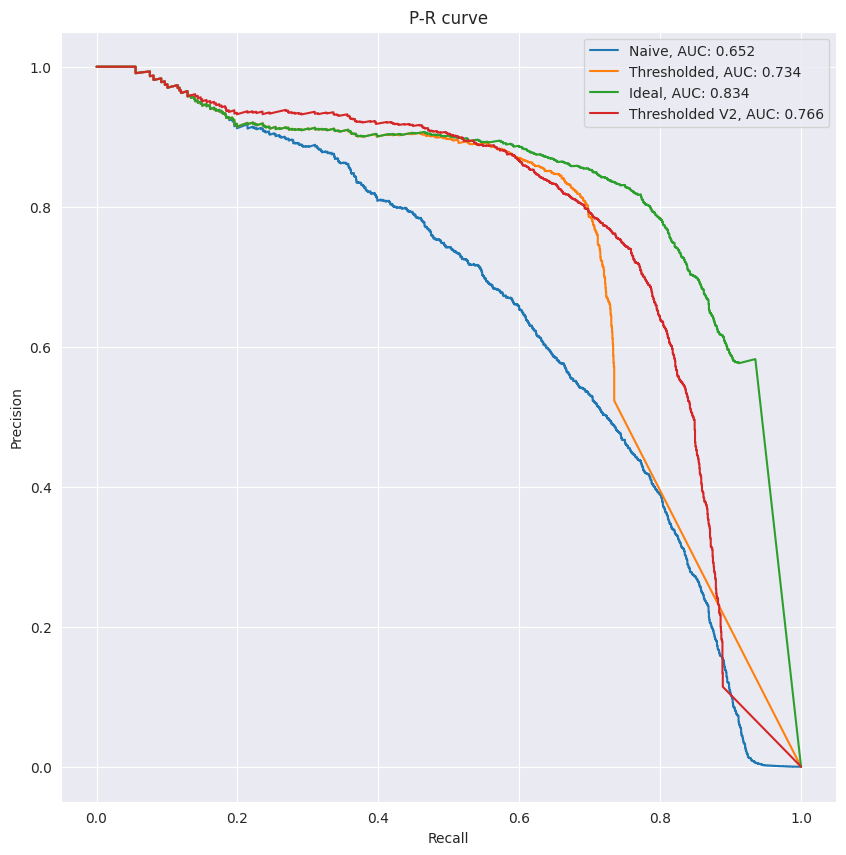

In [29]:

selected_df["threshold_v2"] = (0.9 + 0.1 * selected_df["dom"]) * (1 / (1 + 100 ** (-2 * selected_df["dom"] + 0.5)))
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold_v2"])& (selected_df["pm6a"] > 0.1))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded V2, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


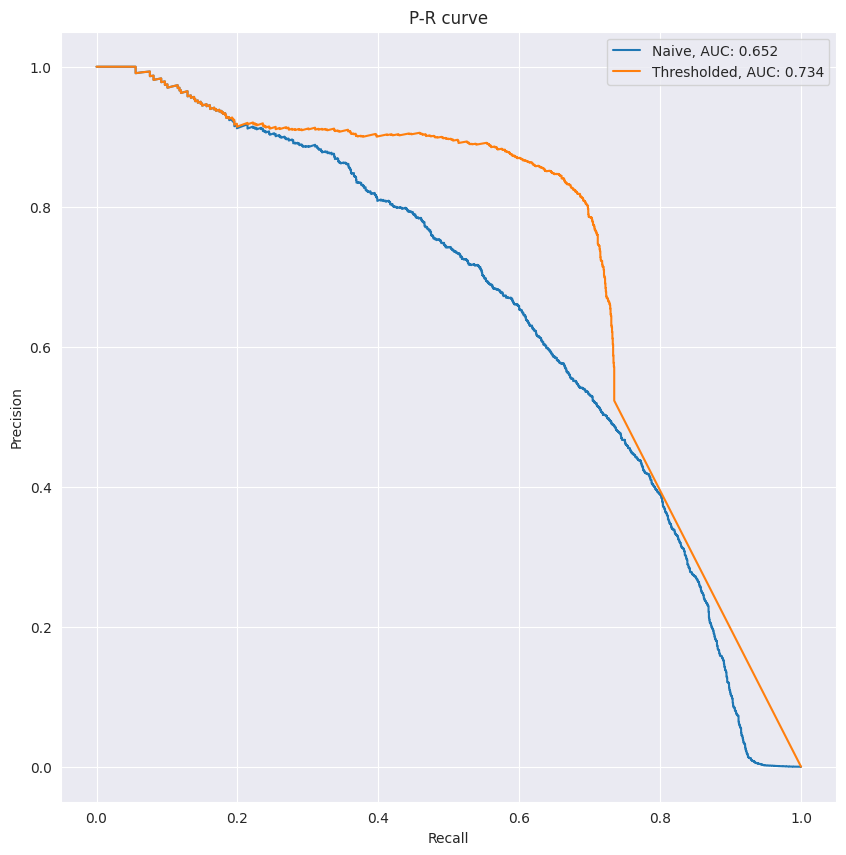

In [36]:

selected_df["threshold_v2"] = 1.02-((0.9 ** (1-cell_label_df["dom"])) * (0.02 ** (1.1*cell_label_df["dom"]-0.1)))
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold_v2"])& (selected_df["pm6a"] > 0.1))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")
# 
# 
# precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
# auc_score = auc(recall, precision)
# ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")
# 
# 
# precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
# auc_score = auc(recall, precision)
# ax.plot(recall, precision, label=f"Thresholded V2, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


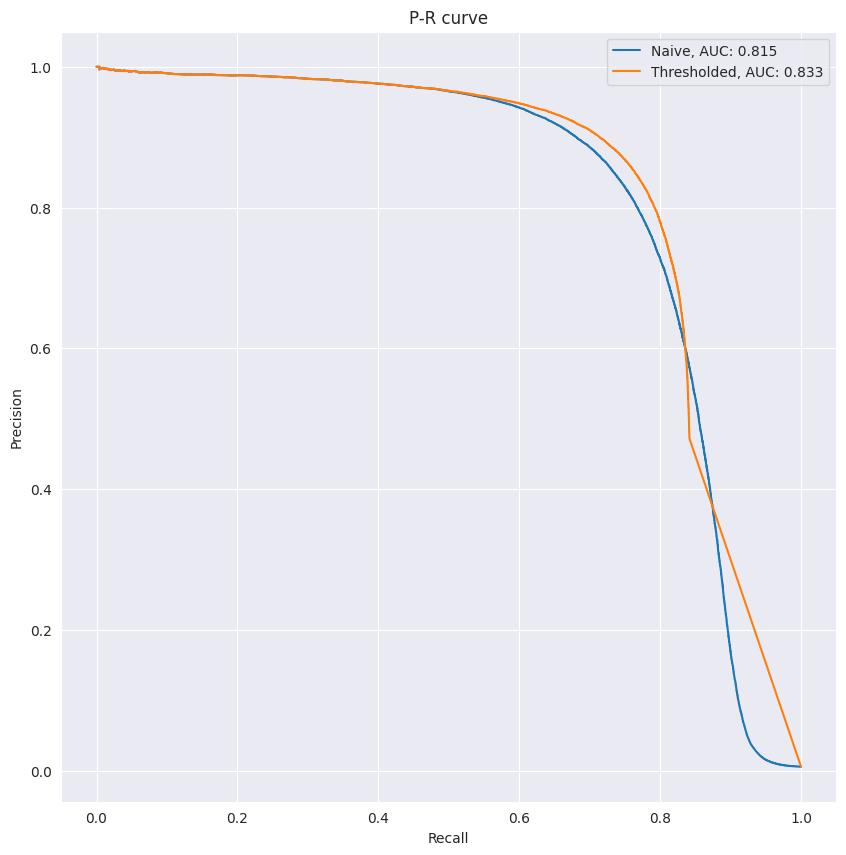

In [38]:
selected_df = cell_label_df[(cell_label_df["count_pm6a"] >= 20) & (cell_label_df["label"] >= 0)]
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}") 
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


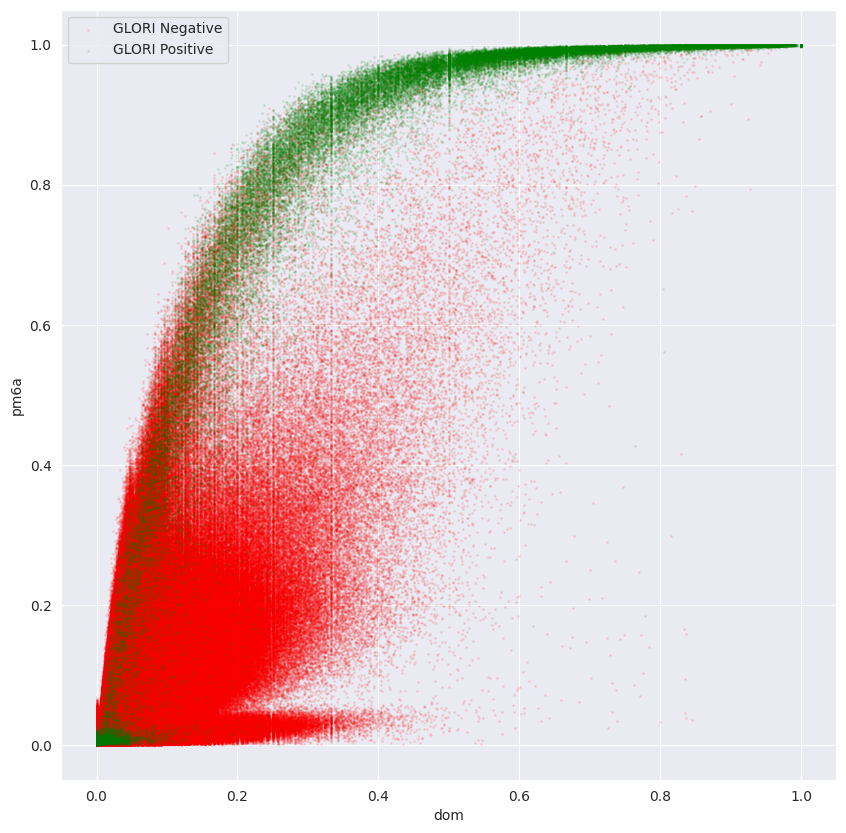

In [31]:

neg_df = cell_label_df[cell_label_df["dom_label"] == 0]
pos_df = cell_label_df[cell_label_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["pm6a"], alpha=0.1, s = 1, color="red", label="GLORI Negative")
ax.scatter(pos_df["dom"], pos_df["pm6a"], alpha=0.1, s = 1, color="green", label="GLORI Positive")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a")
plt.show()
plt.close()